In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.calibration import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report)
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn import metrics
from sklearn.utils.class_weight import compute_class_weight


from imblearn.over_sampling import KMeansSMOTE, SMOTE, ADASYN, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks, EditedNearestNeighbours, RepeatedEditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek


import plotly as py
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from plotly.offline import init_notebook_mode, iplot, plot
import plotly.express as px

In [34]:
df = pd.read_csv('../datasets/processed/heart_no_nans.csv')

In [35]:
data = pd.read_csv('heart_no_nans.csv')
df_original = pd.DataFrame(data)

In [36]:
df_original.duplicated().sum()

196

In [37]:
df_original.drop_duplicates(inplace=True)
df_original.duplicated().sum()

0

In [38]:
df = df_original.copy()

In [39]:
#label encoder

label_encoder = LabelEncoder()

label_columns = ['Sex']

for col in label_columns:
    df[col] = label_encoder.fit_transform(df[col])

df = pd.get_dummies(df, columns=['RaceEthnicityCategory'], drop_first=True)

#ordinal mapping
ordinal_mapping = {
    'GeneralHealth': { "Excellent": 5, "Very good": 4, "Good": 3, "Fair": 2, "Poor": 1 },
    'SmokerStatus': { "Current smoker - now smokes every day": 4,
                     "Current smoker - now smokes some days": 3,
                     "Former smoker": 2,
                     "Never smoked": 1 },
    'ECigaretteUsage': { "Never used e-cigarettes in my entire life": 1,
                         "Use them every day": 4,
                         "Use them some days": 3,
                         "Not at all (right now)": 2 },
    'AgeCategory': { "Age 18 to 24": 1, "Age 25 to 29": 2, "Age 30 to 34": 3,
                    "Age 35 to 39": 4, "Age 40 to 44": 5, "Age 45 to 49": 6,
                    "Age 50 to 54": 7, "Age 55 to 59": 8, "Age 60 to 64": 9,
                    "Age 65 to 69": 10, "Age 70 to 74": 11, "Age 75 to 79": 12,
                    "Age 80 or older": 13 },
    'LastCheckupTime':{'Within past year (anytime less than 12 months ago)': 0,
                    'Within past 2 years (1 year but less than 2 years ago)': 1,
                    'Within past 5 years (2 years but less than 5 years ago)': 2,
                    '5 or more years ago': 3},
    'HadDiabetes':{'No': 0,
                    'No, pre-diabetes or borderline diabetes': 1,
                    'Yes, but only during pregnancy (female)': 2,
                    'Yes': 3},
    'HighBloodPressure':{'No': 0,
                    'No, pre-hypertension or borderline high blood pressure': 1,
                    'Yes, but female told only during pregnancy': 2,
                    'Yes': 3}

}

for col, mapping in ordinal_mapping.items():
    df[col] = df[col].map(mapping)

#Yes No statement
df.replace({'No': 0, 'Yes': 1}, inplace=True)

#state encoding
state_encoding = df.groupby('State')['HadHeartAttack'].mean().to_dict()
df['State'] = df['State'].map(state_encoding)

<ipython-input-39-c63b8f8d9bb8>:47: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [40]:
df['HadHeartAttack'].value_counts(normalize=True) * 100

,proportion
HadHeartAttack,
0,94.354197
1,5.645803


In [41]:
X = df.drop('HadHeartAttack', axis=1)
y = df['HadHeartAttack']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.35, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# **Resampling with SMOTE**

In [42]:
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

print(pd.Series(y_train_resampled).value_counts())

HadHeartAttack
0    157925
1    157925
Name: count, dtype: int64


In [43]:
logreg = LogisticRegression(max_iter=1000, random_state=42, class_weight = 'balanced')
logreg.fit(X_train_resampled, y_train_resampled)

# Prediksi
y_pred_smote = logreg.predict(X_test_scaled)
y_pred_proba_smote = logreg.predict_proba(X_test_scaled)
y_pred_custom = (y_pred_proba_smote[:, 1] > 0.6).astype(int)

# ROC & AUC
fpr_smote, tpr_smote, _ = metrics.roc_curve(y_test, y_pred_proba_smote[:, 1])
auc_smote = round(metrics.auc(fpr_smote, tpr_smote), 5)

# DataFrame evaluasi SMOTE
smote_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom),
    auc_smote
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_SMOTE"])
# Lihat hasil evaluasi
print(smote_eval)

           Logistic_Regression_SMOTE
Accuracy                    0.876761
Precision                   0.266289
Recall                      0.673939
F1-score                    0.381742
AUC                         0.874680



Accuracy of Logistic Regression (with SMOTE): 82.40%

Classification Report for Logistic Regression (with SMOTE):
              precision    recall  f1-score   support

           0       0.98      0.83      0.90     85038
           1       0.21      0.75      0.33      5088

    accuracy                           0.82     90126
   macro avg       0.60      0.79      0.61     90126
weighted avg       0.94      0.82      0.87     90126



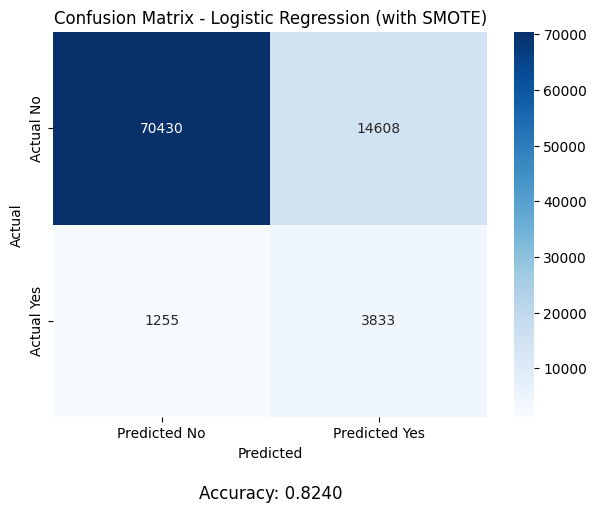

In [44]:
conf_matrix_smote = confusion_matrix(y_test, y_pred_smote)
logreg_acc_score_smote = accuracy_score(y_test, y_pred_smote)

# Print Accuracy
print("\nAccuracy of Logistic Regression (with SMOTE): {:.2f}%".format(logreg_acc_score_smote * 100))

# Print Classification Report
print("\nClassification Report for Logistic Regression (with SMOTE):")
print(classification_report(y_test, y_pred_smote))


plt.figure(figsize=(7, 5))
sns.heatmap(conf_matrix_smote, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted No', 'Predicted Yes'], yticklabels=['Actual No', 'Actual Yes'])

plt.title('Confusion Matrix - Logistic Regression (with SMOTE)')
plt.xlabel('Predicted')
plt.ylabel('Actual')


plt.text(0.5, -0.2, f'Accuracy: {logreg_acc_score_smote:.4f}', ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)

plt.show()

# **Resampling with BORDERLINE SMOTE**

In [45]:
borderline_smote = BorderlineSMOTE(random_state=42, kind='borderline-2')
X_train_resampled_bd, y_train_resampled_bd = borderline_smote.fit_resample(X_train_scaled, y_train)

# Cek hasil resampling
print(pd.Series(y_train_resampled_bd).value_counts())


HadHeartAttack
0    157925
1    157925
Name: count, dtype: int64


In [46]:
logreg_bd = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
logreg_bd.fit(X_train_resampled_bd, y_train_resampled_bd)

# Prediksi
y_pred_bd = logreg_bd.predict(X_test_scaled)
y_pred_proba_bd = logreg_bd.predict_proba(X_test_scaled)
y_pred_custom = (y_pred_proba_bd[:, 1] > 0.8).astype(int)

# ROC & AUC
fpr_bd, tpr_bd, _ = metrics.roc_curve(y_test, y_pred_proba_bd[:, 1])
auc_bd = round(metrics.auc(fpr_bd, tpr_bd), 5)

# DataFrame evaluasi SMOTE
bd_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom),
    auc_smote
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_BroderlineSMOTE"])
# Lihat hasil evaluasi
print(bd_eval)
conf_matrix_blsmote = confusion_matrix(y_test, y_pred_custom)
print(conf_matrix_blsmote)

           Logistic_Regression_BroderlineSMOTE
Accuracy                              0.929055
Precision                             0.404364
Recall                                0.542649
F1-score                              0.463411
AUC                                   0.874680
[[80971  4067]
 [ 2327  2761]]


## **Resampling with RUS**

In [47]:
rus = RandomUnderSampler(random_state=42)
X_train_resampled_rus, y_train_resampled_rus = rus.fit_resample(X_train_scaled, y_train)

print(f"After undersampling: \n{y_train_resampled_rus.value_counts()}")

After undersampling: 
HadHeartAttack
0    9450
1    9450
Name: count, dtype: int64


In [48]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_resampled_rus
)
logreg_rus = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight={0: weights[0]*1.5, 1: weights[1]}
)

In [49]:
logreg_rus.fit(X_train_resampled_rus, y_train_resampled_rus)

# Prediksi
y_pred_rus = logreg_rus.predict(X_test_scaled)
y_pred_proba_rus = logreg_rus.predict_proba(X_test_scaled)
y_pred_custom_rus = (y_pred_proba_rus[:, 1] > 0.8).astype(int)

# ROC & AUC
fpr_rus, tpr_rus, _ = metrics.roc_curve(y_test, y_pred_proba_rus[:, 1])
auc_rus = round(metrics.auc(fpr_rus, tpr_rus), 5)

# DataFrame evaluasi RUS
rus_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom_rus),
    precision_score(y_test, y_pred_custom_rus),
    recall_score(y_test, y_pred_custom_rus),
    f1_score(y_test, y_pred_custom_rus),
    auc_rus
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_RUS"])

# Lihat hasil evaluasi
print(rus_eval)
conf_matrix_rus = confusion_matrix(y_test, y_pred_custom_rus)
print(conf_matrix_rus)

           Logistic_Regression_RUS
Accuracy                  0.940528
Precision                 0.472778
Recall                    0.464230
F1-score                  0.468465
AUC                       0.878140
[[82404  2634]
 [ 2726  2362]]


## **Resampling with ENN**

In [50]:
enn = EditedNearestNeighbours(n_neighbors=3)
X_train_resampled_enn, y_train_resampled_enn = enn.fit_resample(X_train_scaled, y_train)

In [51]:
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train_resampled_enn
)

logreg_enn = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight={0: weights[0]*1.5, 1: weights[1]}
)
logreg_enn.fit(X_train_resampled_enn, y_train_resampled_enn)


LogisticRegression(class_weight={0: 0.7999379958569959, 1: 8.00931216931217},
                   max_iter=1000, random_state=42)

In [52]:
y_pred_enn = logreg_enn.predict(X_test_scaled)
y_pred_proba_enn = logreg_enn.predict_proba(X_test_scaled)
y_pred_custom_enn = (y_pred_proba_enn[:, 1] > 0.8).astype(int)


# ROC & AUC
fpr_enn, tpr_enn, _ = metrics.roc_curve(y_test, y_pred_proba_enn[:, 1])
auc_enn = round(metrics.auc(fpr_enn, tpr_enn), 5)

# DataFrame evaluasi ENN
enn_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom_enn),
    precision_score(y_test, y_pred_custom_enn),
    recall_score(y_test, y_pred_custom_enn),
    f1_score(y_test, y_pred_custom_enn),
    auc_enn
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_ENN"])

print(enn_eval)

# Confusion Matrix
conf_matrix_enn = confusion_matrix(y_test, y_pred_custom_enn)
print(conf_matrix_enn)

           Logistic_Regression_ENN
Accuracy                  0.930719
Precision                 0.413809
Recall                    0.545401
F1-score                  0.470578
AUC                       0.879150
[[81107  3931]
 [ 2313  2775]]


## **Resampling with NearMiss**

In [53]:
nm = NearMiss(version=3)
X_train_resampled_nm, y_train_resampled_nm = nm.fit_resample(X_train_scaled, y_train)
print(pd.Series(y_train_resampled_nm).value_counts())

HadHeartAttack
0    9450
1    9450
Name: count, dtype: int64


In [54]:
logreg_nm = LogisticRegression(max_iter=1000, random_state=42)
logreg_nm.fit(X_train_resampled_nm, y_train_resampled_nm)

# prediction
y_pred_proba_nm = logreg_nm.predict_proba(X_test_scaled)
y_pred_nm = (y_pred_proba_nm[:, 1] > 0.66).astype(int)  # Adjust threshold to prioritize precision

# ROC & AUC
fpr_nm, tpr_nm, _ = metrics.roc_curve(y_test, y_pred_proba_nm[:, 1])
auc_nm = round(roc_auc_score(y_test, y_pred_proba_nm[:, 1]), 5)

# Evaluation
nm_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_nm),
    precision_score(y_test, y_pred_nm),
    recall_score(y_test, y_pred_nm),
    f1_score(y_test, y_pred_nm),
    auc_nm
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_NearMiss"])


print(nm_eval)

conf_matrix_nm = confusion_matrix(y_test, y_pred_nm)
print(conf_matrix_nm)

           Logistic_Regression_NearMiss
Accuracy                       0.919280
Precision                      0.303221
Recall                         0.331171
F1-score                       0.316581
AUC                            0.690580
[[81166  3872]
 [ 3403  1685]]


## **Resampling with SMOTETomek**

In [55]:
smt = SMOTETomek(random_state=42)
X_train_final, y_train_final = smt.fit_resample(X_train_scaled, y_train)

print(pd.Series(y_train_final).value_counts())

HadHeartAttack
0    157913
1    157913
Name: count, dtype: int64


In [56]:
logreg_tlsm = LogisticRegression(max_iter=1000, random_state=42)
logreg_tlsm.fit(X_train_final, y_train_final)

# Prediksi
y_pred_tl = logreg_tlsm.predict(X_test_scaled)
y_pred_proba_tl = logreg_tlsm.predict_proba(X_test_scaled)
y_pred_custom = (y_pred_proba_tl[:, 1] > 0.8).astype(int)

# ROC & AUC
fpr_tl, tpr_tl, _ = metrics.roc_curve(y_test, y_pred_proba_tl[:, 1])
auc_bd = round(metrics.auc(fpr_tl, tpr_tl), 5)

# DataFrame evaluasi SMOTE
tl_eval = pd.DataFrame(data=[
    accuracy_score(y_test, y_pred_custom),
    precision_score(y_test, y_pred_custom),
    recall_score(y_test, y_pred_custom),
    f1_score(y_test, y_pred_custom),
    auc_smote
], index=['Accuracy', 'Precision', 'Recall', 'F1-score', 'AUC'], columns=["Logistic_Regression_SMOTETomek"])
# Lihat hasil evaluasi
print(tl_eval)

           Logistic_Regression_SMOTETomek
Accuracy                         0.931607
Precision                        0.415806
Recall                           0.522209
F1-score                         0.462973
AUC                              0.874680
